In [1]:
import pandas as pd
import os

# Load the Truth file
truth_path = os.path.join(r"c:\Python\Personal\kfm-ms\codes\pest", "master_truth.csv")
df_truth = pd.read_csv(truth_path)

# Extract unique well locations in the order of their ID
truth_locs = df_truth.sort_values("well_id")[['r', 'c']].drop_duplicates().values.tolist()

print("Well Locations in Truth File (sorted by well_id):")
for i, loc in enumerate(truth_locs):
    print(f"ID {i}: {loc}")


Well Locations in Truth File (sorted by well_id):
ID 0: [22, 11]
ID 1: [9, 40]
ID 2: [17, 43]
ID 3: [43, 23]
ID 4: [33, 31]
ID 5: [26, 22]
ID 6: [37, 37]
ID 7: [32, 8]
ID 8: [9, 28]
ID 9: [31, 38]


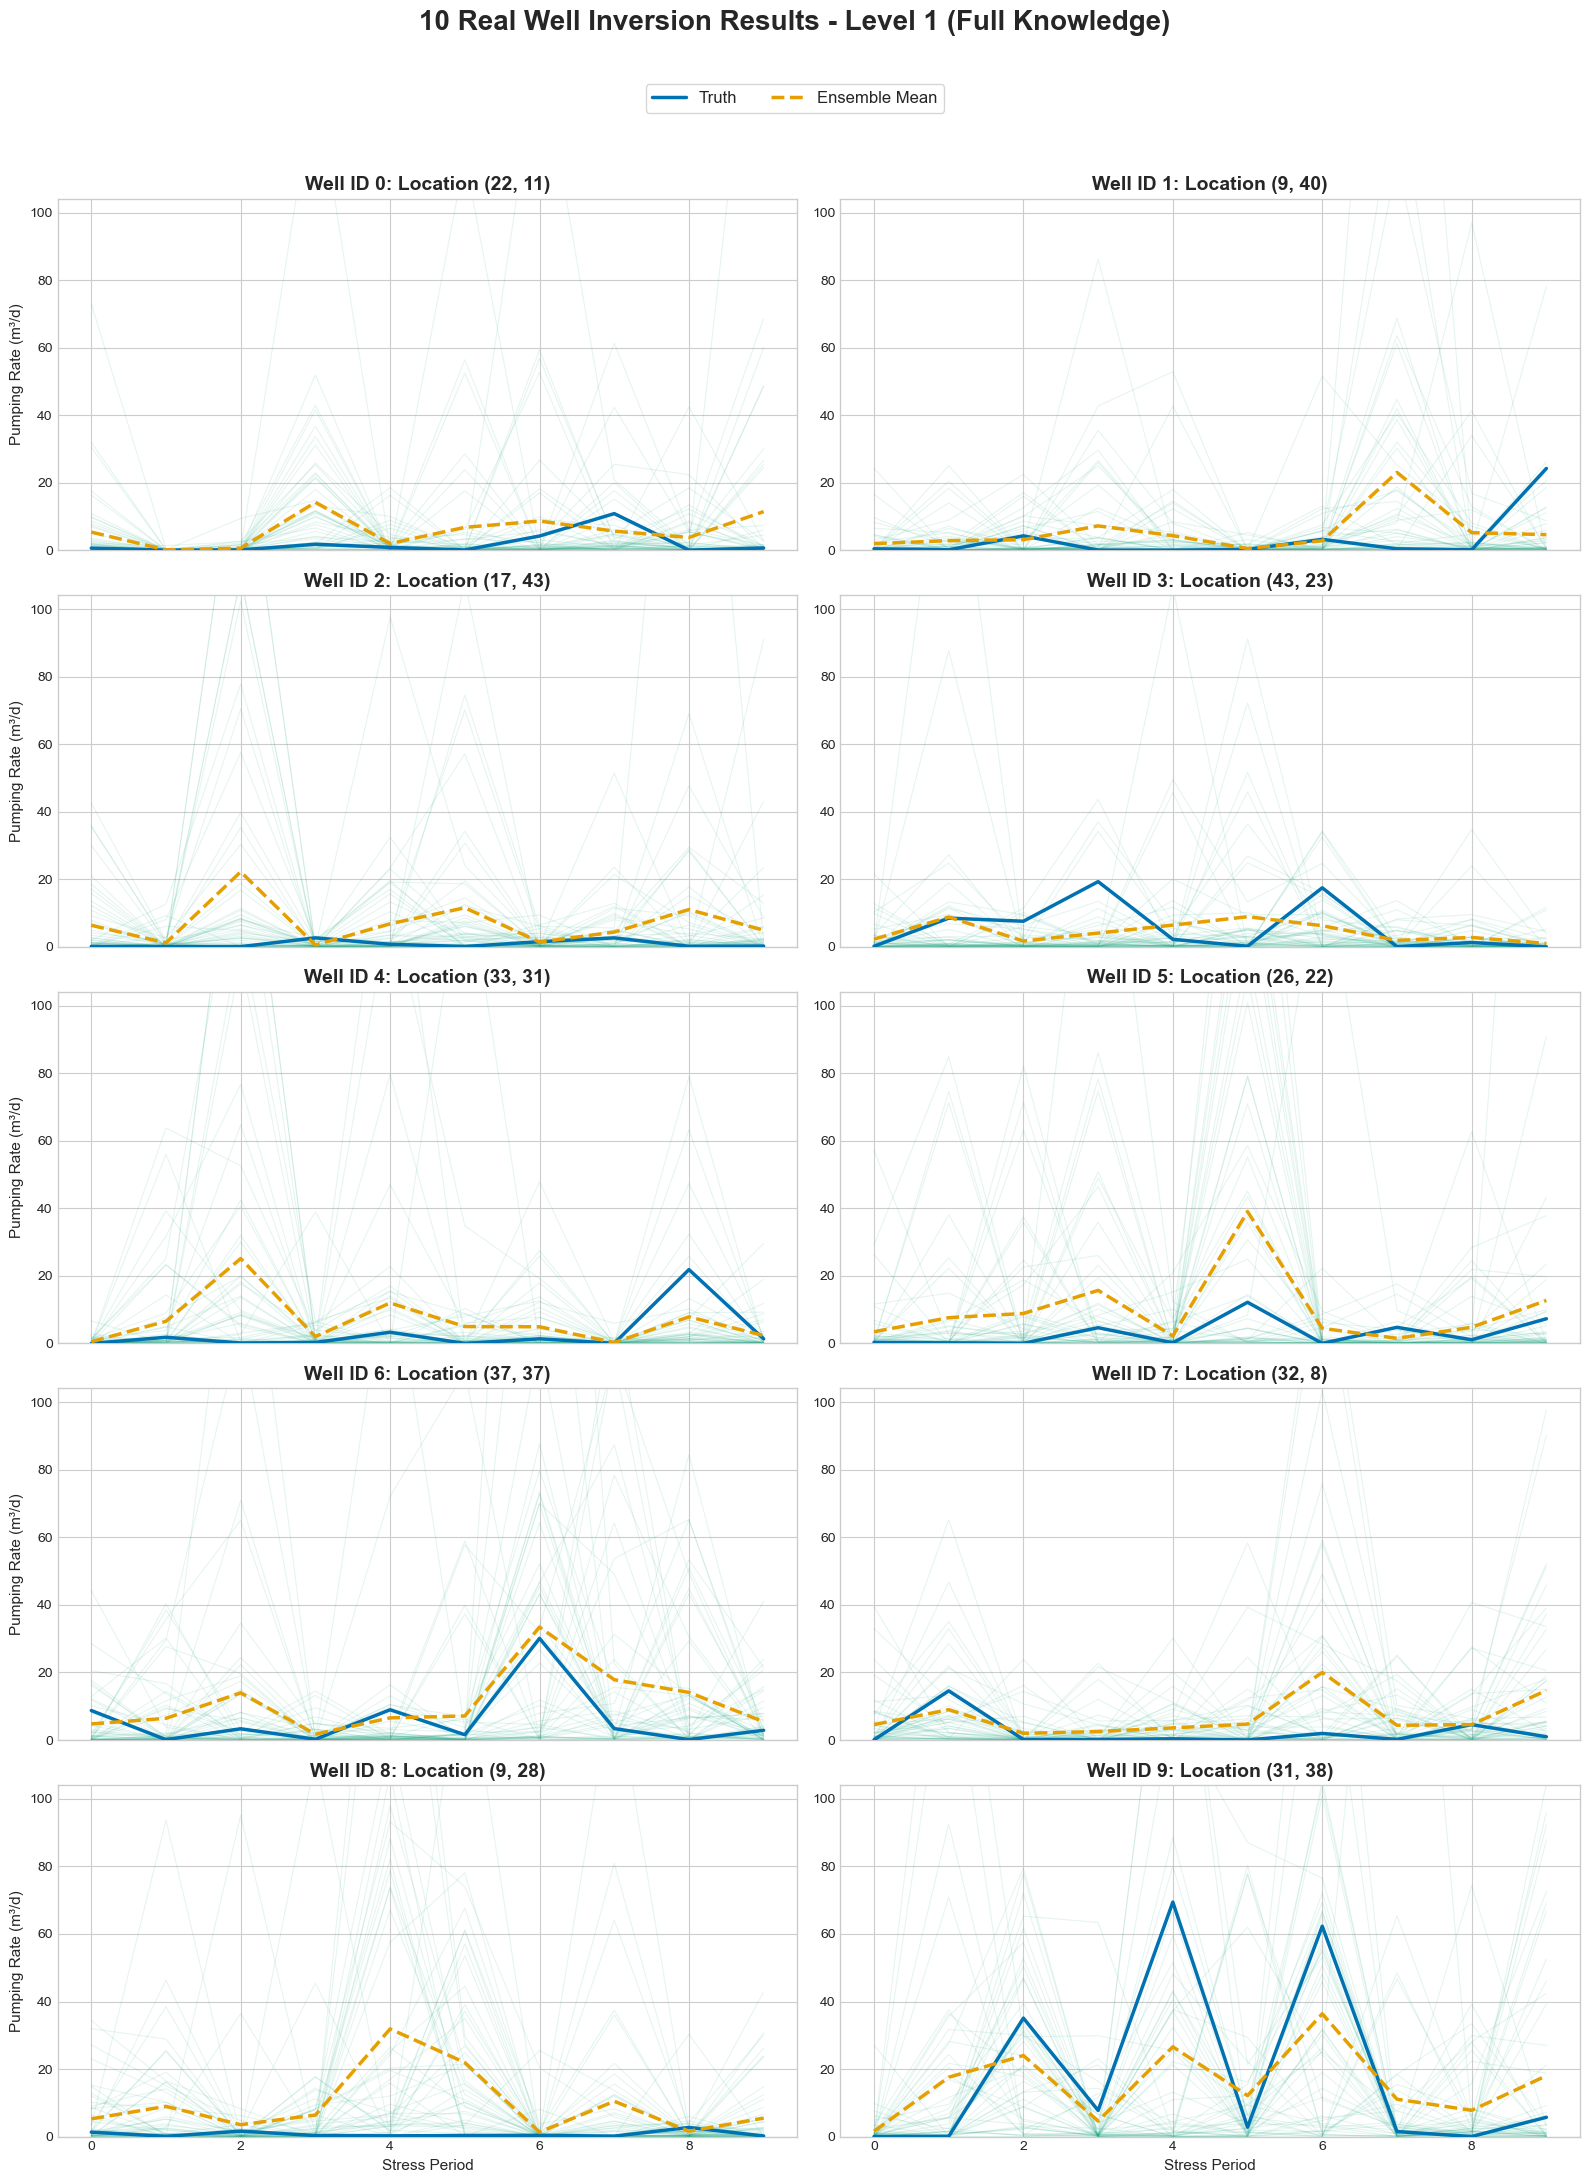

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl

# format
mpl.rcParams['font.family'] = 'Arial'
plt.style.use('seaborn-v0_8-whitegrid')

PEST_DIR = r"c:\Python\Personal\kfm-ms\codes\pest"

# load data
df_truth = pd.read_csv(os.path.join(PEST_DIR, "master_truth.csv"))
df_pars = pd.read_csv(os.path.join(PEST_DIR, "inversion_level_1.10.par.csv"), index_col=0)

# identify the 10 unique wells sorted by ID
unique_wells = df_truth.sort_values("well_id")[['well_id', 'r', 'c']].drop_duplicates()

# setup plotting grid
fig, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=True)
axes = axes.flatten()

for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    w_id, r, c = int(row.well_id), int(row.r), int(row.c)
    well_tag = f"r:{r}_c:{c}"
    
    # extract and sort columns by SP
    well_cols = [col for col in df_pars.columns if well_tag in col]
    well_cols.sort(key=lambda x: int(x.split("sp:")[1].split("_")[0]))
    
    # plot ensemble
    for real in df_pars.index:
        ax.plot(df_pars.loc[real, well_cols].values, color='#009E73', alpha=0.1, linewidth=0.8)
        
    # plot truth
    truth_q = df_truth[(df_truth.well_id == w_id)].sort_values("sp").q.values
    ax.plot(truth_q, label="Truth", color='#0072B2', marker='none', markersize=6, linewidth=2.5, zorder=10)
    
    # plot ensemble mean
    mean_q = df_pars[well_cols].mean()
    ax.plot(mean_q.values, label="Ensemble Mean", color='#E69F00', linestyle='--', linewidth=2.5, zorder=11)
    
    # Formatting each subplot
    ax.set_title(f"Well ID {w_id}: Location ({r}, {c})", fontsize=14, fontweight='bold')
    ax.set_ylim(0, df_truth['q'].max() * 1.5) # Consistent Y-axis for comparison
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    if i % 2 == 0:
        ax.set_ylabel("Pumping Rate (m³/d)", fontsize=11)
    if i >= 8:
        ax.set_xlabel("Stress Period", fontsize=11)

# format
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.99))
plt.suptitle(f"{len(unique_wells)} Real Well Inversion Results - Level 1 (Full Knowledge)", fontsize=20, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# plt.savefig("Level1_MultiPanel_Results.png", dpi=300, bbox_inches='tight')
plt.show()
